# 🏦 Banking Fraud Analysis and Financial Transaction Intelligence Dashboard

## Major Project

### Project Overview

Financial fraud is one of the biggest challenges faced by modern banking institutions. Millions of transactions are processed every day, making it difficult to identify fraudulent activities manually.

This project performs a complete end-to-end banking fraud analysis using Python, SQL, Statistics, and Power BI. The project demonstrates data collection, preprocessing, exploratory data analysis, feature engineering, SQL analysis, statistical analysis, KPI generation, and dashboard preparation.

---

### Problem Statement

To analyze banking transaction data, identify fraudulent transactions, discover fraud patterns, generate business insights, and prepare data for business intelligence dashboards.

---

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQLite
- SciPy
- VS Code Notebook
- Power BI
- Git & GitHub

# Project Objectives

The objectives of this project are:

- Import banking transaction dataset
- Perform data cleaning
- Handle missing values
- Remove duplicate records
- Detect outliers
- Perform Exploratory Data Analysis (EDA)
- Create professional visualizations
- Apply Advanced Pandas
- Perform SQL Analysis
- Generate Statistical Insights
- Feature Creation
- Time-Series Analysis
- Business KPI Generation
- Dashboard Preparation
- Business Recommendations

# Import Required Libraries

The following libraries are used throughout the project for data analysis, visualization, statistics, SQL, and feature creation.

In [8]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# SQL Database
import sqlite3

# Statistics
from scipy import stats

# Date & Time
from datetime import datetime

# File Handling
from pathlib import Path

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization Style
plt.style.use("ggplot")
sns.set_style("whitegrid")

print("✅ All Libraries Imported Successfully")

✅ All Libraries Imported Successfully


# Load Dataset

The banking fraud dataset is stored on the Desktop and loaded into a Pandas DataFrame for further analysis.

In [9]:
# ==========================================================
# Load Dataset
# ==========================================================

file_path = Path.home() / "Desktop" / "creditcard.csv"

df = pd.read_csv(file_path)

print("✅ Dataset Loaded Successfully")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

✅ Dataset Loaded Successfully
Rows    : 284807
Columns : 31


In [10]:
# Display First 10 Rows

df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [11]:
# Display Random Sample

df.sample(10, random_state=42)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43428,41505.0,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,-14.110184,5.299236,-10.834006,1.671120,-9.373859,0.360806,-9.899247,-19.236292,-8.398552,3.101735,-1.514923,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19,1
49906,44261.0,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,-0.565012,-0.087670,0.979427,0.076883,-0.217884,-0.136830,-2.142892,0.126956,1.752662,0.432546,0.506044,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12,0
29474,35484.0,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,0.756801,0.543827,0.112453,1.075384,-0.245772,0.180483,1.769860,-0.533172,-0.533300,1.192245,0.212877,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00,0
276481,167123.0,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,-1.376648,-1.328335,0.223621,1.132627,-0.550875,0.616568,0.497974,0.502195,0.981343,0.101264,-0.244633,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50,0
278846,168473.0,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,0.259452,0.942162,0.850038,-0.616166,0.592634,-0.603845,0.091077,-0.471867,-0.333816,0.404711,-0.255293,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89,0
101565,67878.0,-0.641330,-0.057304,1.489998,-1.688131,-1.151043,0.259996,-1.391069,-2.334075,1.168644,-2.084080,0.480381,0.473738,-2.192276,0.773942,0.294484,0.406074,-0.541855,1.031450,0.017076,0.618411,-1.231634,0.257164,-0.371953,-0.038566,1.397514,-0.665947,0.031003,0.180357,100.00,0
260880,159763.0,2.023952,-0.120140,-1.086918,0.423019,-0.142901,-1.127752,0.178493,-0.303234,0.564509,0.062831,-0.720047,0.366835,-0.110857,0.319094,0.108359,-0.153633,-0.221312,-0.934141,0.070553,-0.210864,-0.276175,-0.697708,0.335631,-0.017196,-0.324904,0.200023,-0.071566,-0.058224,16.99,0
214337,139631.0,-0.688944,1.292153,-0.564281,-1.457526,2.258333,-0.323270,1.678984,-0.104128,-1.285351,-1.303435,0.282728,-0.402525,-0.548687,-0.504283,-0.685339,0.714828,-0.092674,0.798953,-0.150085,-0.037150,-0.006880,-0.171568,-0.720019,-0.419435,1.211991,0.670916,-0.103986,0.030084,8.95,0
201575,133944.0,2.119362,0.142639,-2.373337,0.541949,0.608419,-1.775564,0.955775,-0.599383,0.010420,0.295305,-0.936569,-0.452478,-1.340798,1.077459,-0.099584,-0.815072,0.018481,-0.639446,-0.065427,-0.323573,0.264264,0.898266,-0.168063,0.059311,0.626949,0.729035,-0.129120,-0.094713,10.00,0
81055,58769.0,-5.584256,-4.732413,-0.448452,-0.121442,-0.707412,-0.114376,-1.554628,1.402126,-0.031693,-0.942358,-2.439501,-0.552312,-0.295588,-0.250246,-1.197732,1.549553,0.933237,-1.237689,0.416832,-1.046900,0.041651,0.621789,0.223467,-0.770137,0.621182,-0.028738,0.505194,-1.898323,101.49,0


In [12]:
# Basic Dataset Information

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print("\n")

print("=" * 60)
print("Column Names")
print("=" * 60)

for col in df.columns:
    print(col)

print("\n")

print("=" * 60)
print("Dataset Information")
print("=" * 60)

df.info()

Dataset Shape
(284807, 31)


Column Names
Time
V1
V2
V3
V4
V5
V6
V7
V8
V9
V10
V11
V12
V13
V14
V15
V16
V17
V18
V19
V20
V21
V22
V23
V24
V25
V26
V27
V28
Amount
Class


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 

# Dataset Overview

Before cleaning and analyzing the dataset, it is important to understand its overall structure.

The following analysis includes:

- Dataset Shape
- Number of Rows
- Number of Columns
- Feature Names
- Dataset Information
- Memory Usage

In [13]:
# ==========================================================
# Dataset Shape
# ==========================================================

print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])
print("\nDataset Shape :", df.shape)

Number of Rows    : 284807
Number of Columns : 31

Dataset Shape : (284807, 31)


In [14]:
# ==========================================================
# Display All Column Names
# ==========================================================

print("Columns in the Dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the Dataset:

1. Time
2. V1
3. V2
4. V3
5. V4
6. V5
7. V6
8. V7
9. V8
10. V9
11. V10
12. V11
13. V12
14. V13
15. V14
16. V15
17. V16
18. V17
19. V18
20. V19
21. V20
22. V21
23. V22
24. V23
25. V24
26. V25
27. V26
28. V27
29. V28
30. Amount
31. Class


In [15]:
# ==========================================================
# Dataset Information
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# Descriptive Statistics

Descriptive statistics help summarize the numerical features present in the dataset.

The following statistics will be calculated:

- Count
- Mean
- Standard Deviation
- Minimum
- 25th Percentile
- Median
- 75th Percentile
- Maximum

In [16]:
# ==========================================================
# Descriptive Statistics
# ==========================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [17]:
# ==========================================================
# Check Missing Values
# ==========================================================

missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

print("\nTotal Missing Values :", missing_values.sum())

Missing Values in Each Column:

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total Missing Values : 0


In [18]:
# ==========================================================
# Check Duplicate Records
# ==========================================================

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 1081


In [19]:
# ==========================================================
# Count Unique Values
# ==========================================================

unique_values = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes
})

unique_values

,Unique Values,Data Type
Time,124592,float64
V1,275663,float64
V2,275663,float64
V3,275663,float64
V4,275663,float64
V5,275663,float64
V6,275663,float64
V7,275663,float64
V8,275663,float64
V9,275663,float64


In [20]:
# ==========================================================
# Memory Usage
# ==========================================================

memory = df.memory_usage(deep=True) / (1024 * 1024)

memory_df = pd.DataFrame({
    "Column": memory.index,
    "Memory Usage (MB)": memory.values
})

print(f"Total Memory Usage: {memory.sum():.2f} MB")

memory_df

Total Memory Usage: 67.36 MB


,Column,Memory Usage (MB)
0,Index,0.000122
1,Time,2.172905
2,V1,2.172905
3,V2,2.172905
4,V3,2.172905
5,V4,2.172905
6,V5,2.172905
7,V6,2.172905
8,V7,2.172905
9,V8,2.172905


# Data Cleaning and Preprocessing

Data cleaning improves the quality of the dataset before analysis.

The following tasks are performed:

- Handle missing values
- Remove duplicate records
- Verify data consistency
- Prepare the dataset for analysis

In [21]:
# ==========================================================
# Missing Values Summary
# ==========================================================

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df)) * 100
})

missing_summary

,Missing Values,Percentage (%)
Time,0,0.0
V1,0,0.0
V2,0,0.0
V3,0,0.0
V4,0,0.0
V5,0,0.0
V6,0,0.0
V7,0,0.0
V8,0,0.0
V9,0,0.0


In [22]:
# ==========================================================
# Fill Missing Values (if any)
# ==========================================================

df = df.fillna(method="ffill")

print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


In [23]:
# ==========================================================
# Remove Duplicate Records
# ==========================================================

rows_before = df.shape[0]

df = df.drop_duplicates()

rows_after = df.shape[0]

print("Rows Before :", rows_before)
print("Rows After  :", rows_after)
print("Duplicates Removed :", rows_before - rows_after)

Rows Before : 284807
Rows After  : 283726
Duplicates Removed : 1081


In [24]:
# ==========================================================
# Verify Dataset Shape After Cleaning
# ==========================================================

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (283726, 31)


# Outlier Detection

Outliers can affect statistical analysis and model performance.

We use the **Interquartile Range (IQR)** method to estimate the number of outliers in each numerical feature.

In [25]:
# ==========================================================
# Detect Outliers Using IQR
# ==========================================================

numeric_columns = df.select_dtypes(include=["number"]).columns

outlier_counts = {}

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_df = pd.DataFrame({
    "Column": outlier_counts.keys(),
    "Outlier Count": outlier_counts.values()
})

outlier_df

,Column,Outlier Count
0,Time,0
1,V1,6948
2,V2,13390
3,V3,3306
4,V4,11094
5,V5,12221
6,V6,22886
7,V7,8839
8,V8,23904
9,V9,8199


In [26]:
# ==========================================================
# Data Types Verification
# ==========================================================

datatype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

datatype_df

,Column,Data Type
0,Time,float64
1,V1,float64
2,V2,float64
3,V3,float64
4,V4,float64
5,V5,float64
6,V6,float64
7,V7,float64
8,V8,float64
9,V9,float64


In [27]:
# ==========================================================
# Check Class Distribution
# ==========================================================

class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    283253
1       473
Name: count, dtype: int64


In [28]:
# ==========================================================
# Class Distribution Percentage
# ==========================================================

class_percentage = (df["Class"].value_counts(normalize=True) * 100).round(4)

class_percentage

Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the distribution, patterns, and relationships within the banking transaction dataset.

The following analyses are included:

- Fraud vs Non-Fraud Transactions
- Transaction Amount Distribution
- Transaction Time Distribution
- Feature Distributions
- Correlation Analysis
- Business Insights

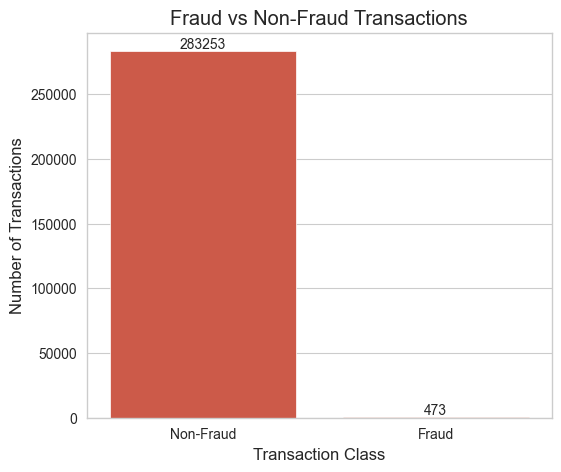

In [29]:
# ==========================================================
# Class Distribution
# ==========================================================

plt.figure(figsize=(6,5))

ax = sns.countplot(data=df, x="Class")

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

ax.set_xticklabels(["Non-Fraud", "Fraud"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Insight

The dataset is highly imbalanced.

- Class 0 represents legitimate transactions.
- Class 1 represents fraudulent transactions.

This imbalance is common in fraud detection datasets and should be considered during further analysis.

In [30]:
# ==========================================================
# Fraud Percentage
# ==========================================================

fraud_percentage = (
    df["Class"].value_counts(normalize=True) * 100
).round(4)

fraud_percentage

Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64

In [31]:
# ==========================================================
# Transaction Amount Statistics
# ==========================================================

df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

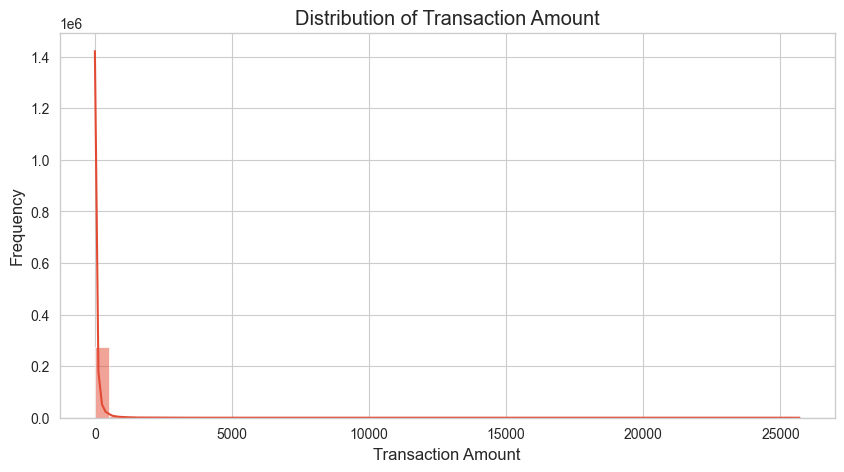

In [32]:
# ==========================================================
# Distribution of Transaction Amount
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=50, kde=True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

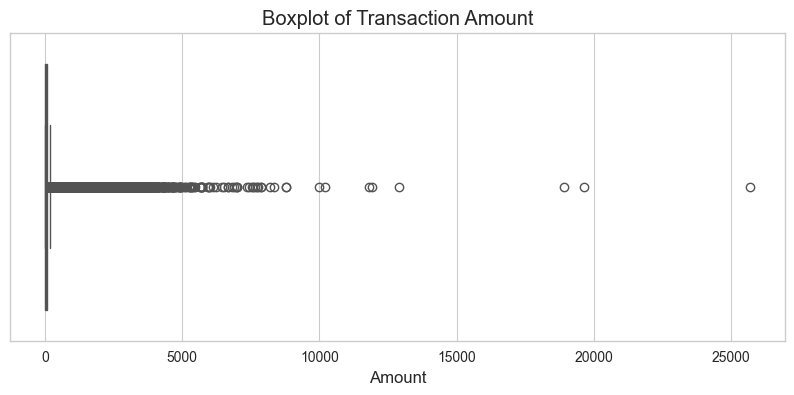

In [33]:
# ==========================================================
# Transaction Amount Boxplot
# ==========================================================

plt.figure(figsize=(10,4))

sns.boxplot(x=df["Amount"])

plt.title("Boxplot of Transaction Amount")

plt.show()

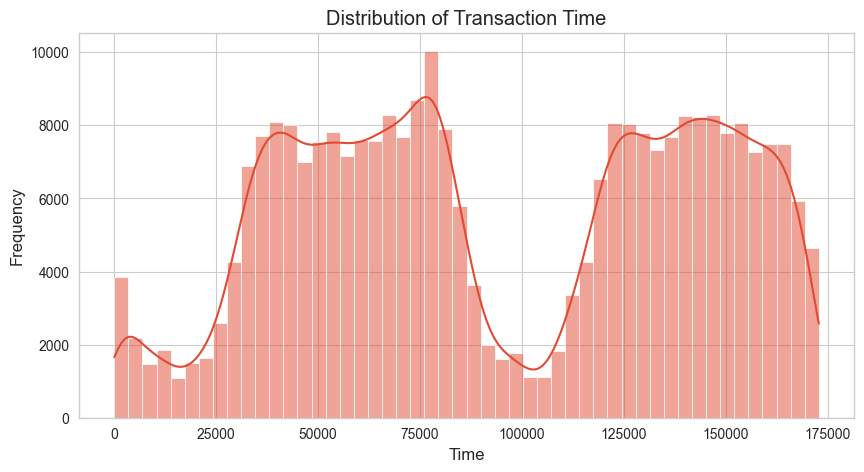

In [34]:
# ==========================================================
# Transaction Time Distribution
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50, kde=True)

plt.title("Distribution of Transaction Time")

plt.xlabel("Time")

plt.ylabel("Frequency")

plt.show()

In [35]:
# ==========================================================
# Average Amount by Transaction Class
# ==========================================================

average_amount = (
    df.groupby("Class")["Amount"]
      .mean()
      .reset_index()
)

average_amount["Class"] = average_amount["Class"].map(
    {0: "Non-Fraud", 1: "Fraud"}
)

average_amount

,Class,Amount
0,Non-Fraud,88.413575
1,Fraud,123.871860


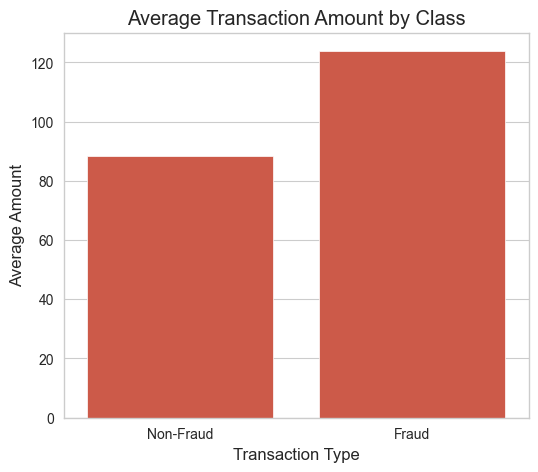

In [36]:
# ==========================================================
# Average Amount Visualization
# ==========================================================

plt.figure(figsize=(6,5))

sns.barplot(
    data=average_amount,
    x="Class",
    y="Amount"
)

plt.title("Average Transaction Amount by Class")

plt.xlabel("Transaction Type")

plt.ylabel("Average Amount")

plt.show()

# Feature Distribution Analysis

The dataset contains anonymized features (`V1` to `V28`) that were created using Principal Component Analysis (PCA).

In this section, we explore the distribution of selected features to better understand their behavior and identify unusual patterns.

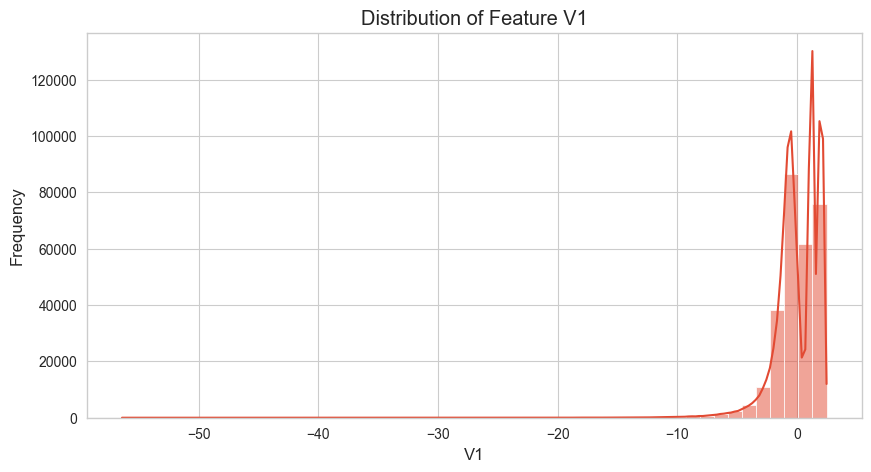

In [37]:
# ==========================================================
# Distribution of V1
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(df["V1"], bins=50, kde=True)

plt.title("Distribution of Feature V1")

plt.xlabel("V1")

plt.ylabel("Frequency")

plt.show()

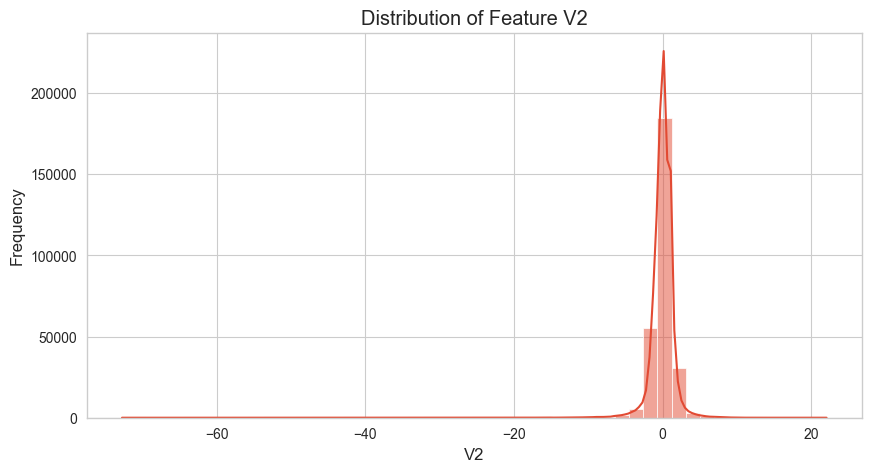

In [38]:
# ==========================================================
# Distribution of V2
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(df["V2"], bins=50, kde=True)

plt.title("Distribution of Feature V2")

plt.xlabel("V2")

plt.ylabel("Frequency")

plt.show()

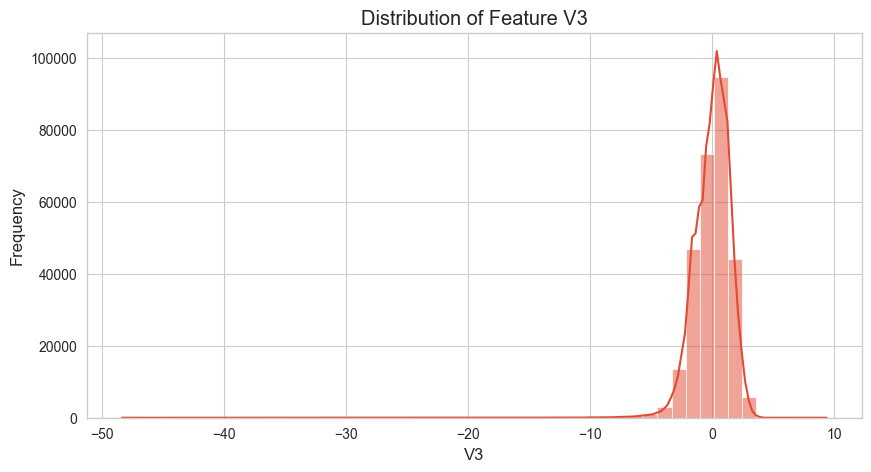

In [40]:
# ==========================================================
# Distribution of V3
# ==========================================================

plt.figure(figsize=(10,5))

sns.histplot(df["V3"], bins=50, kde=True)

plt.title("Distribution of Feature V3")

plt.xlabel("V3")

plt.ylabel("Frequency")

plt.show()

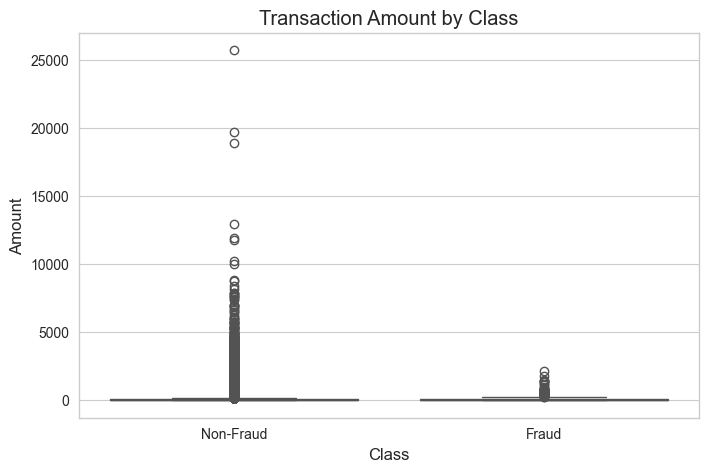

In [41]:
# ==========================================================
# Boxplot of Transaction Amount by Class
# ==========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.xticks([0,1], ["Non-Fraud", "Fraud"])

plt.title("Transaction Amount by Class")

plt.show()

### Business Insight

Comparing transaction amounts across fraud and non-fraud classes helps identify whether fraudulent transactions tend to occur in specific value ranges. This insight can support fraud monitoring strategies.

In [42]:
# ==========================================================
# Correlation Matrix
# ==========================================================

correlation_matrix = df.corr()

correlation_matrix.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,0.031068,-0.248536,0.125500,-0.065958,-0.100316,-0.184392,0.011286,-0.073819,0.090305,0.029537,-0.051022,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,0.000815,0.001028,-0.001524,-0.000568,-0.002663,-0.000602,-0.003345,-0.003491,-0.003535,0.000919,-0.001393,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,0.000620,-0.000633,0.002266,0.000680,0.002711,0.001538,0.004013,0.003244,0.002477,-0.000358,-0.001287,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,-0.009632,0.002339,-0.005900,0.000113,-0.003027,-0.001230,-0.004430,-0.008159,-0.003495,-0.000016,-0.002269,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,0.002753,-0.001223,0.003366,0.000177,0.002801,0.000572,0.003346,0.003655,0.002325,-0.000560,0.000318,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326


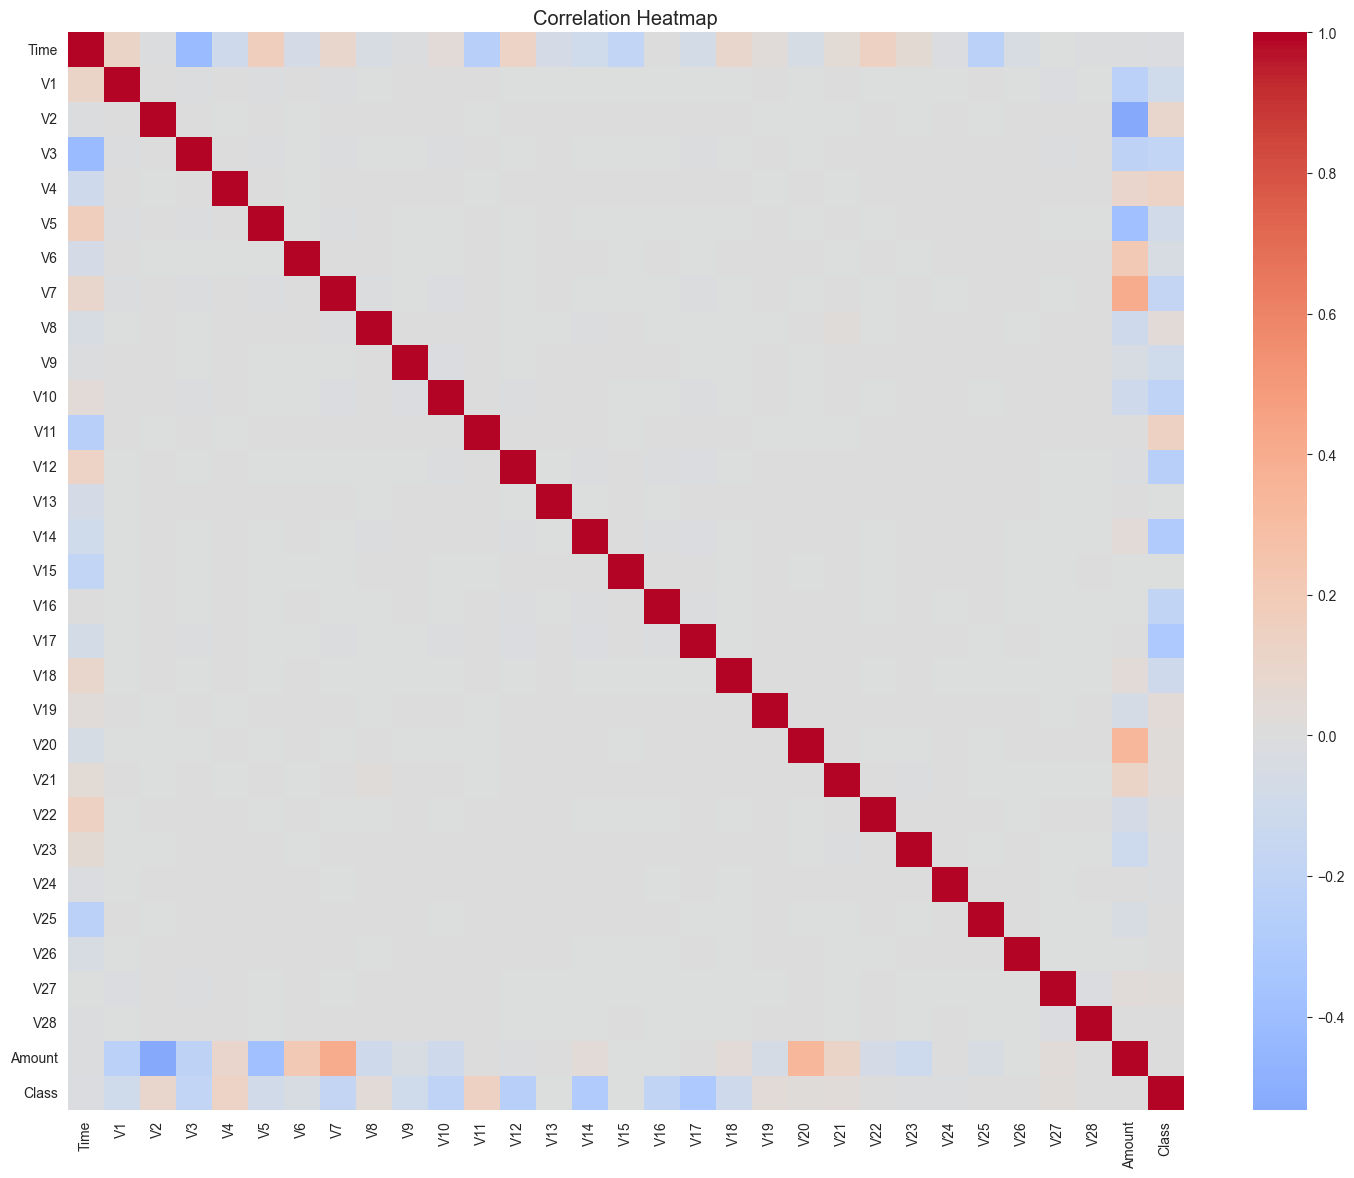

In [43]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(18,14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [44]:
# ==========================================================
# Correlation with Target Variable (Class)
# ==========================================================

class_correlation = (
    correlation_matrix["Class"]
    .sort_values(ascending=False)
)

class_correlation

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64

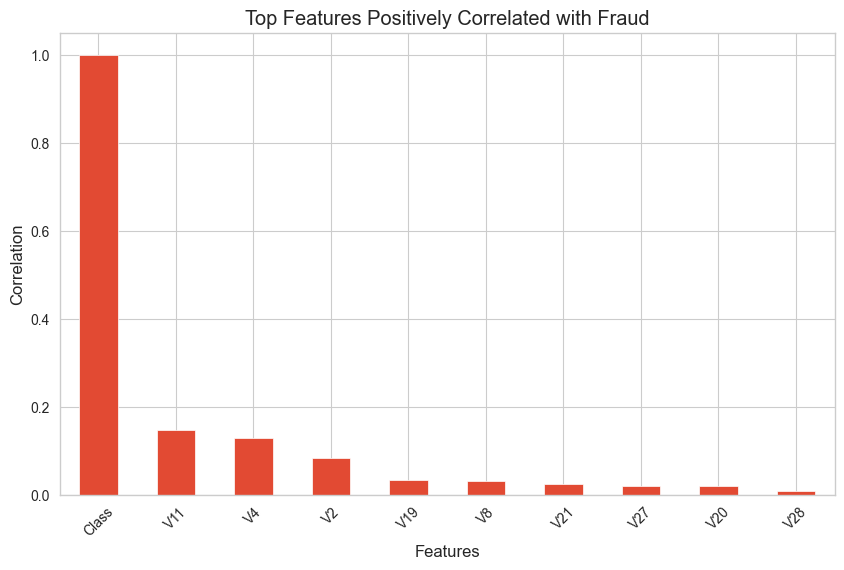

In [45]:
# ==========================================================
# Top 10 Features Correlated with Fraud
# ==========================================================

top_positive = class_correlation.head(10)

plt.figure(figsize=(10,6))

top_positive.plot(kind="bar")

plt.title("Top Features Positively Correlated with Fraud")

plt.xlabel("Features")

plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()

# Advanced Data Visualization

Visualization helps identify hidden patterns, trends, and relationships within the banking transaction dataset.

In this section, we use both Matplotlib and Seaborn to explore transaction behavior and fraud characteristics.

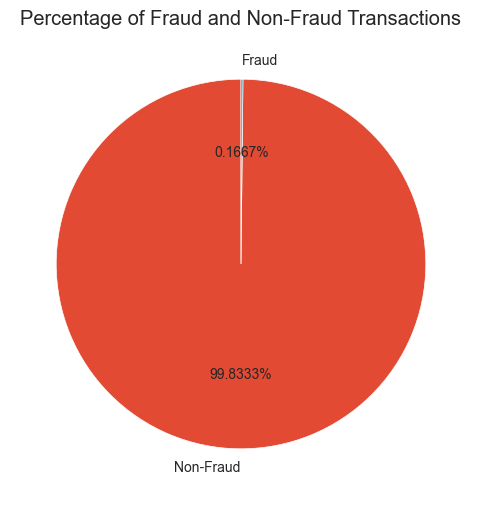

In [46]:
# ==========================================================
# Fraud vs Non-Fraud Percentage Chart
# ==========================================================

fraud_percent = (
    df["Class"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

plt.figure(figsize=(6,6))

plt.pie(
    fraud_percent,
    labels=["Non-Fraud", "Fraud"],
    autopct="%1.4f%%",
    startangle=90
)

plt.title("Percentage of Fraud and Non-Fraud Transactions")

plt.show()

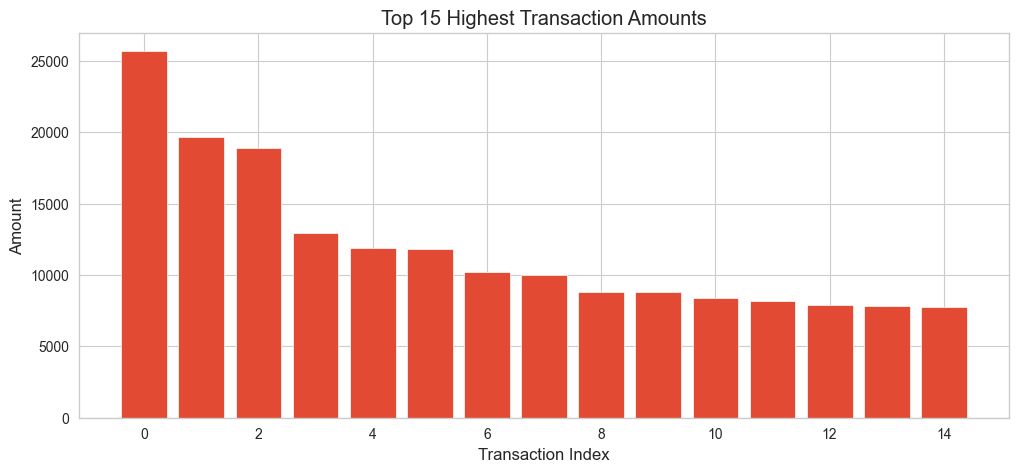

In [47]:
# ==========================================================
# Top 15 Highest Transaction Amounts
# ==========================================================

top_transactions = df.nlargest(15, "Amount")

plt.figure(figsize=(12,5))

plt.bar(
    range(len(top_transactions)),
    top_transactions["Amount"]
)

plt.title("Top 15 Highest Transaction Amounts")

plt.xlabel("Transaction Index")

plt.ylabel("Amount")

plt.show()

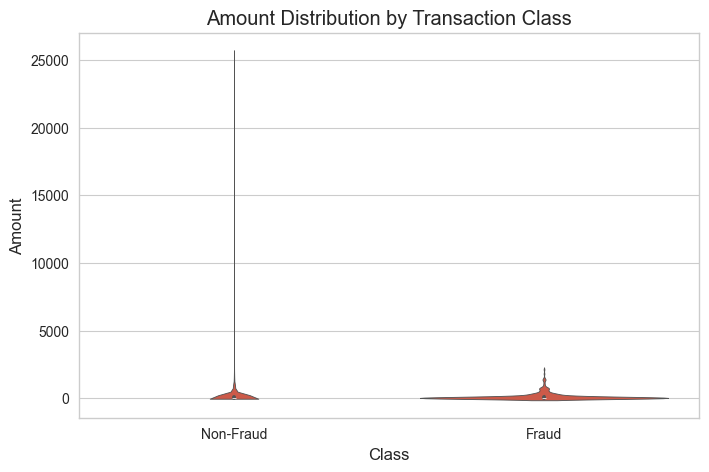

In [48]:
# ==========================================================
# Amount Distribution by Fraud Class
# ==========================================================

plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.xticks([0,1], ["Non-Fraud", "Fraud"])

plt.title("Amount Distribution by Transaction Class")

plt.show()

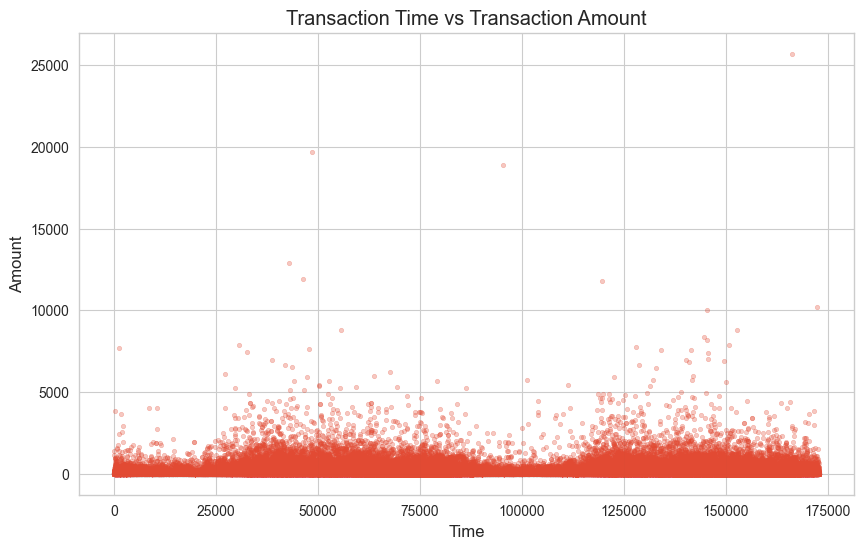

In [49]:
# ==========================================================
# Scatter Plot: Time vs Amount
# ==========================================================

plt.figure(figsize=(10,6))

plt.scatter(
    df["Time"],
    df["Amount"],
    alpha=0.3,
    s=10
)

plt.title("Transaction Time vs Transaction Amount")

plt.xlabel("Time")

plt.ylabel("Amount")

plt.show()

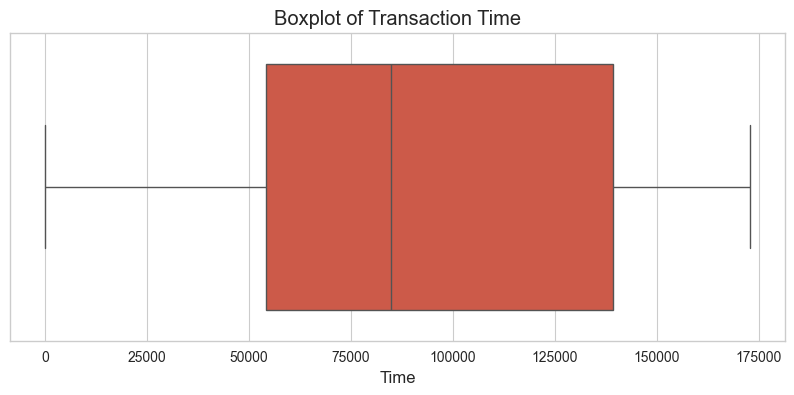

In [52]:
# ==========================================================
# Boxplot of Time
# ==========================================================

plt.figure(figsize=(10,4))

sns.boxplot(x=df["Time"])

plt.title("Boxplot of Transaction Time")

plt.show()

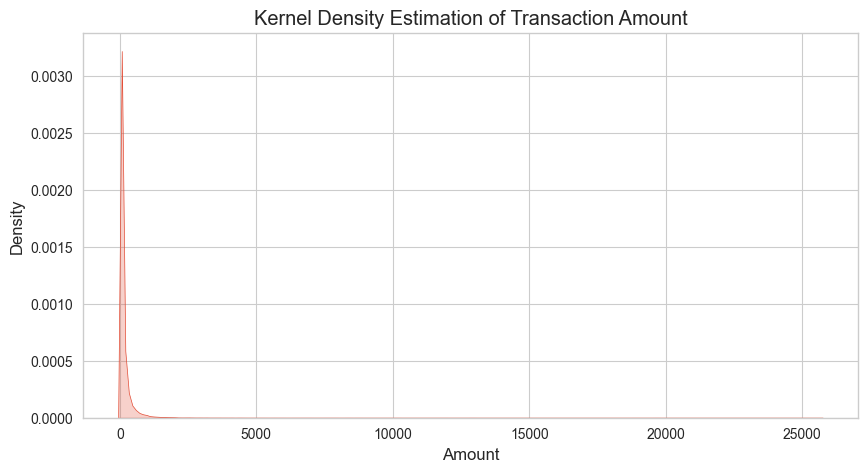

In [53]:
# ==========================================================
# KDE Plot of Transaction Amount
# ==========================================================

plt.figure(figsize=(10,5))

sns.kdeplot(df["Amount"], fill=True)

plt.title("Kernel Density Estimation of Transaction Amount")

plt.xlabel("Amount")

plt.show()

In [54]:
# ==========================================================
# Correlation of Top Features with Fraud
# ==========================================================

top_corr = (
    correlation_matrix["Class"]
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

top_corr

Class    1.000000
V17      0.313498
V14      0.293375
V12      0.250711
V10      0.206971
V16      0.187186
V3       0.182322
V7       0.172347
V11      0.149067
V4       0.129326
Name: Class, dtype: float64

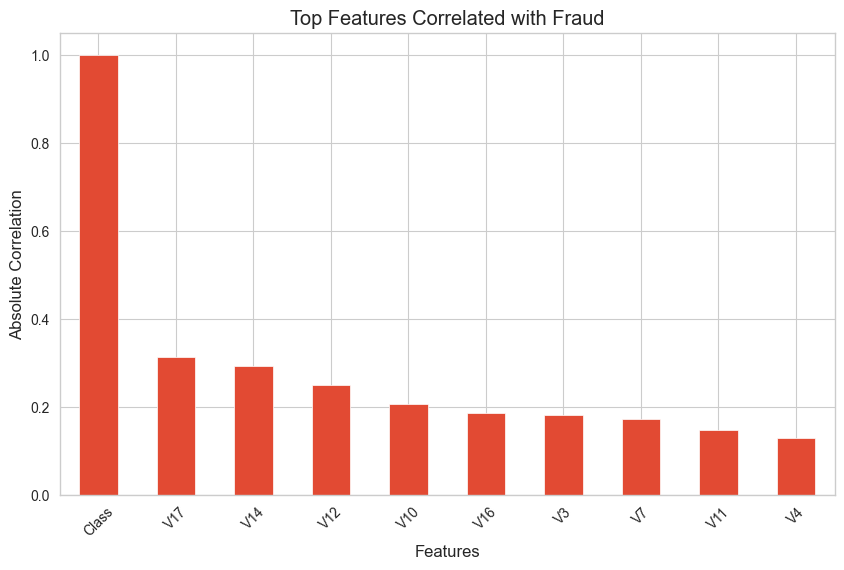

In [55]:
# ==========================================================
# Bar Chart of Top Correlated Features
# ==========================================================

plt.figure(figsize=(10,6))

top_corr.plot(kind="bar")

plt.title("Top Features Correlated with Fraud")

plt.xlabel("Features")

plt.ylabel("Absolute Correlation")

plt.xticks(rotation=45)

plt.show()

# EDA Summary

### Key Findings

- The dataset is highly imbalanced, with legitimate transactions significantly outnumbering fraudulent ones.
- Transaction amounts exhibit a right-skewed distribution, indicating many low-value transactions and relatively few high-value transactions.
- Correlation analysis identifies a subset of features with stronger relationships to the fraud indicator (`Class`), which can be useful for further investigation.
- Visual exploration provides a foundation for advanced statistical analysis, SQL-based reporting, and dashboard development.

The next section will focus on advanced data manipulation using Pandas.

# Advanced Pandas Analysis

Advanced Pandas provides powerful tools for transforming, summarizing, and analyzing data.

This section demonstrates:

- Feature Engineering
- GroupBy Operations
- Aggregation
- Binning
- Pivot Tables
- Sorting and Ranking

In [56]:
# ==========================================================
# Create Transaction Category
# ==========================================================

bins = [-1, 10, 50, 100, 500, df["Amount"].max()]

labels = [
    "Very Low",
    "Low",
    "Medium",
    "High",
    "Very High"
]

df["Amount_Category"] = pd.cut(
    df["Amount"],
    bins=bins,
    labels=labels
)

df[["Amount", "Amount_Category"]].head(10)

,Amount,Amount_Category
0,149.62,High
1,2.69,Very Low
2,378.66,High
3,123.50,High
4,69.99,Medium
5,3.67,Very Low
6,4.99,Very Low
7,40.80,Low
8,93.20,Medium
9,3.68,Very Low


In [57]:
# ==========================================================
# Transactions by Amount Category
# ==========================================================

amount_category_summary = (
    df.groupby("Amount_Category")
      .size()
      .reset_index(name="Total Transactions")
)

amount_category_summary

,Amount_Category,Total Transactions
0,Very Low,99821
1,Low,90327
2,Medium,37179
3,High,47290
4,Very High,9109


In [58]:
# ==========================================================
# Average Amount by Transaction Class
# ==========================================================

class_summary = (
    df.groupby("Class")
      .agg(
          Total_Transactions=("Class", "count"),
          Average_Amount=("Amount", "mean"),
          Maximum_Amount=("Amount", "max"),
          Minimum_Amount=("Amount", "min")
      )
)

class_summary

,Total_Transactions,Average_Amount,Maximum_Amount,Minimum_Amount
Class,,,,
0,283253,88.413575,25691.16,0.0
1,473,123.871860,2125.87,0.0


In [59]:
# ==========================================================
# Multiple Aggregations
# ==========================================================

amount_statistics = (
    df.groupby("Amount_Category")
      .agg({
          "Amount": ["count", "mean", "median", "max", "min", "std"]
      })
)

amount_statistics

Amount                                                    
                 count         mean   median       max     min         std
Amount_Category                                                           
Very Low         99821     3.888416    2.390     10.00    0.00    3.249657
Low              90327    25.969395   23.680     50.00   10.01   11.787479
Medium           37179    73.307195   71.900    100.00   50.01   14.686568
High             47290   212.601039  179.445    500.00  100.01  100.691085
Very High         9109  1052.665188  795.260  25691.16  500.04  877.666465

In [60]:
# ==========================================================
# Pivot Table
# ==========================================================

pivot_table = pd.pivot_table(
    df,
    values="Amount",
    index="Amount_Category",
    columns="Class",
    aggfunc="mean"
)

pivot_table

Class,0,1
Amount_Category,,
Very Low,3.893197,1.887857
Low,25.968160,27.996727
Medium,73.284691,88.496909
High,212.564903,231.343736
Very High,1053.228050,902.430882


In [61]:
# ==========================================================
# Top 20 Highest Transactions
# ==========================================================

top20 = (
    df.sort_values(
        by="Amount",
        ascending=False
    )
    .head(20)
)

top20

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_Category
274771,166198.0,-35.548539,-31.850484,-48.325589,15.304184,-113.743307,73.301626,120.589494,-27.347360,-3.872425,-12.005487,6.853897,-9.189418,7.126883,-6.795942,8.877742,17.315112,-7.173805,-1.968044,5.501747,-54.497720,-21.620120,5.712303,-1.581098,4.584549,4.554683,3.415636,31.612198,-15.430084,25691.16,0,Very High
58465,48401.0,-36.802320,-63.344698,-20.645794,16.715537,-20.672064,7.694002,24.956587,-4.730111,-2.687312,-8.423404,1.186360,1.879982,3.496723,4.082503,1.406178,0.773133,0.902964,5.041069,-7.213527,39.420904,11.455313,-10.933144,-17.173665,1.180700,-7.025783,-2.534330,-3.602479,3.450224,19656.53,0,Very High
151296,95286.0,-34.549296,-60.464618,-21.340854,16.875344,-19.229075,6.335259,24.422716,-4.964566,0.188912,-8.908182,-0.083514,-2.281866,3.739366,5.989210,2.582162,3.032874,0.530779,4.712398,-6.938297,38.117209,11.502580,-9.499423,-16.513186,0.744341,-7.081325,-2.604551,-3.550963,3.250802,18910.00,0,Very High
46841,42951.0,-23.712839,-42.172688,-13.320825,9.925019,-13.945538,5.564891,15.710644,-2.844253,-1.580725,-5.533256,1.446695,0.902675,1.746979,2.354131,0.801598,2.068475,1.413407,0.748320,-3.637371,26.237391,7.921600,-6.320710,-11.310338,0.404175,-4.547278,-1.577118,-2.357385,2.253662,12910.93,0,Very High
54018,46253.0,-21.780665,-38.305310,-12.122469,9.752791,-12.880794,4.256017,14.785051,-2.818253,-0.667338,-5.545590,1.067549,0.832726,1.592166,2.788521,2.569520,2.721505,-0.613875,3.490798,-3.838863,24.133894,7.437478,-5.619439,-10.547038,0.653249,-4.232409,-0.480459,-2.257913,2.082488,11898.09,0,Very High
169457,119713.0,-20.924897,-37.943452,-14.060281,10.473005,-10.866639,6.256654,14.960521,-2.392155,-0.597076,-5.341249,0.713033,1.361297,1.410760,2.969936,1.441114,1.134212,0.297532,1.340820,-4.392421,23.649095,6.829810,-6.926353,-9.928657,-0.447084,-4.848151,-2.241620,-2.140723,2.001492,11789.84,0,Very High
284249,172273.0,-9.030538,-11.112584,-16.233798,3.592021,-40.427726,23.917837,44.054461,-7.277778,-4.210637,-7.776435,0.214173,-4.499851,0.241005,0.537895,2.901938,2.326099,-0.402142,1.257379,2.008145,2.454553,-0.269048,0.988144,7.040028,0.347693,2.520869,2.342495,3.478175,-2.713136,10199.44,0,Very High
227921,145283.0,-21.532478,-34.704768,-8.303035,10.264175,3.957175,-3.229695,-4.066768,-4.083971,0.554072,-2.166867,0.939705,3.108922,0.808613,4.109779,3.017039,0.554018,1.174609,0.601035,-4.353679,19.746453,5.198718,-7.331078,-32.828995,0.118986,-8.696627,-1.778061,-0.519786,2.716716,10000.00,0,Very High
74699,55709.0,-16.950064,-16.417395,-12.523381,6.555638,-27.752964,18.072031,28.504065,-10.152220,2.124673,-2.856014,0.121804,-1.619834,2.231107,-3.041540,2.630401,5.000096,-1.745472,-1.129167,2.639624,-19.902611,-5.932594,0.050097,-10.855949,1.550407,-0.502172,0.821714,12.152401,-4.009839,8790.26,0,Very High
245474,152763.0,-14.641710,-28.554825,-12.714462,5.878264,-7.855074,2.471004,11.922577,-2.651203,-2.223985,-2.973570,0.340516,-0.204348,0.966013,2.677857,0.071213,1.634390,0.341256,0.799556,-1.522014,17.819507,5.788207,-3.269671,-8.024556,0.423021,-2.396701,-0.633380,-1.763704,1.422017,8787.00,0,Very High


In [62]:
# ==========================================================
# Lowest 20 Transactions
# ==========================================================

lowest20 = (
    df.sort_values(
        by="Amount",
        ascending=True
    )
    .head(20)
)

lowest20

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_Category
84293,60240.0,-0.400545,0.945926,1.679598,1.175528,0.220309,0.034641,0.466287,0.036702,-0.624131,0.081718,-1.379232,-0.207596,0.156696,-0.392023,-0.740504,0.376277,-0.323738,-0.591173,0.061224,-0.062585,-0.272949,-0.756520,-0.051644,-0.122859,-0.189548,0.732615,-0.169642,0.010626,0.0,0,Very Low
219965,141958.0,-0.704680,2.432447,0.607578,4.609899,-0.000312,0.450919,-0.640970,-2.312292,-2.712909,0.745708,-0.838659,0.333382,0.685855,0.967740,0.059763,-0.222629,0.658794,-0.470475,1.053440,0.678005,-1.327571,0.189183,0.405851,0.415137,-1.074919,-0.025859,0.073500,0.201061,0.0,0,Very Low
219958,141955.0,-1.585532,1.240411,-0.558349,-0.841657,0.397502,-1.532723,0.388818,0.575896,-0.278370,-0.856928,-1.118925,0.737224,0.479263,0.795002,-0.396345,-0.362278,0.049958,-0.648354,0.009054,-0.120858,-0.045525,-0.096605,-0.249493,0.001462,-0.045791,-0.110667,0.305249,0.015271,0.0,0,Very Low
56576,47492.0,-0.412717,0.883816,1.691434,2.978105,-0.326557,1.544135,-0.861962,1.059913,-0.881150,0.550788,0.953201,0.902137,0.102824,0.199880,-0.005799,-0.389663,0.606888,-0.189675,0.396144,-0.092495,0.275306,0.910519,0.280340,-0.281648,-1.670943,0.011281,0.238050,0.175215,0.0,0,Very Low
23856,32954.0,1.112786,0.062772,1.481419,2.922471,-0.905121,0.366357,-0.670663,0.256586,0.599399,0.411398,-1.515738,-0.163763,-1.048557,-0.540107,-1.385328,0.073163,0.056735,-0.196746,-0.559959,-0.247537,0.010125,0.346740,-0.117334,0.416103,0.586102,0.216021,0.042710,0.024984,0.0,0,Very Low
168326,119171.0,-0.018210,0.950521,-0.921959,-0.645477,1.832459,-1.182104,1.715612,-0.454249,-0.942553,-0.503891,-1.258906,-0.368721,-0.232638,0.678605,-0.593139,-0.653135,-0.334273,-0.429516,-0.073582,-0.118592,0.279919,0.824769,-0.568966,0.570116,1.005800,0.711873,-0.136078,-0.061115,0.0,0,Very Low
13981,24841.0,-1.272463,0.109749,1.856980,0.779493,2.778831,4.479380,-0.976314,1.349414,1.149108,-0.768577,-0.420979,-2.629624,1.279855,0.628524,-2.603328,0.763728,-0.135689,0.469888,-1.150783,0.018585,-0.222250,-0.506601,-0.252085,0.938008,0.581209,-0.115783,0.026599,0.072614,0.0,0,Very Low
125445,77678.0,1.299959,0.195338,-0.236376,0.419654,0.373313,-0.039490,0.202971,-0.124102,0.081927,-0.182632,-0.926062,0.606577,0.961147,-0.013294,0.267739,-0.419717,-0.092088,-0.921003,0.081719,-0.076413,-0.086243,-0.001858,-0.191774,-0.667082,0.735323,0.633195,-0.030834,-0.009316,0.0,0,Very Low
180445,124543.0,1.981596,0.766670,-2.008529,3.545828,1.385911,-0.249485,0.885531,-0.183365,-1.732397,1.804290,0.339826,-0.449413,-1.650145,1.275139,-1.653840,0.298612,-0.648518,-0.094220,-1.187179,-0.387276,0.310266,0.849467,-0.102548,0.698778,0.613624,0.318235,-0.116135,-0.086042,0.0,0,Very Low
13988,24856.0,-3.019163,-0.867828,0.185889,1.180677,3.176214,3.274869,-2.163350,1.982751,0.701305,-0.729323,-0.349883,-2.311010,1.684206,1.703811,-1.603134,1.491173,-0.189706,0.625629,-1.465606,-0.471950,-0.118212,-0.595009,-0.783634,1.004245,-0.335976,-0.327891,0.126779,-0.580409,0.0,0,Very Low


In [63]:
# ==========================================================
# Ranking Transactions by Amount
# ==========================================================

df["Transaction_Rank"] = (
    df["Amount"]
    .rank(
        ascending=False,
        method="dense"
    )
)

df[["Amount", "Transaction_Rank"]].head()

,Amount,Transaction_Rank
0,149.62,19265.0
1,2.69,32499.0
2,378.66,9274.0
3,123.50,21218.0
4,69.99,25862.0


In [67]:
from pathlib import Path

desktop = Path.home() / "Desktop"

output_path = desktop / "cleaned_creditcard.csv"

df.to_csv(output_path, index=False)

print("✅ File saved successfully!")
print(output_path)

✅ File saved successfully!
/Users/s/Desktop/cleaned_creditcard.csv


# SQL Analysis Using SQLite

Structured Query Language (SQL) is widely used in banking to query, filter, summarize, and analyze transactional data.

In this section, the cleaned dataset is loaded into a SQLite database, and various SQL queries are performed to extract meaningful insights.

In [70]:
# ==========================================================
# Create SQLite Database
# ==========================================================

import sqlite3
from pathlib import Path

desktop = Path.home() / "Desktop"
db_path = desktop / "banking_fraud.db"

conn = sqlite3.connect(db_path)

print("✅ SQLite Database Created Successfully")
print("Database Location:", db_path)

✅ SQLite Database Created Successfully
Database Location: /Users/s/Desktop/banking_fraud.db


In [71]:
# ==========================================================
# Export DataFrame to SQLite
# ==========================================================

df.to_sql(
    "transactions",
    conn,
    if_exists="replace",
    index=False
)

print("✅ Dataset Imported into SQLite")

✅ Dataset Imported into SQLite


In [72]:
# ==========================================================
# SQL Query 1 - SELECT
# ==========================================================

query = """

SELECT *

FROM transactions

LIMIT 10;

"""

sql_df = pd.read_sql(query, conn)

sql_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_Category,Transaction_Rank
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,High,19265.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,Very Low,32499.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,High,9274.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,High,21218.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,Medium,25862.0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0,Very Low,32401.0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0,Very Low,32269.0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0,Low,28696.0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0,Medium,23746.0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0,Very Low,32400.0


In [73]:
# ==========================================================
# SQL Query 2 - WHERE
# ==========================================================

query = """

SELECT *

FROM transactions

WHERE Class = 1

LIMIT 20;

"""

fraud_transactions = pd.read_sql(query, conn)

fraud_transactions

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_Category,Transaction_Rank
0,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,3.202033,-2.899907,-0.595222,-4.289254,0.389724,-1.140747,-2.830056,-0.016822,0.416956,0.126911,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1,Very Low,32767.0
1,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,-0.414575,-0.503141,0.676502,-1.692029,2.000635,0.666780,0.599717,1.725321,0.283345,2.102339,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1,Very High,6389.0
2,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,2.032912,-6.560124,0.022937,-1.470102,-0.698826,-2.282194,-4.781831,-2.615665,-1.334441,-0.430022,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1,High,14033.0
3,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,-4.801637,4.895844,-10.912819,0.184372,-6.771097,-0.007326,-7.358083,-12.598419,-5.131549,0.308334,-0.171608,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1,Medium,26915.0
4,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,-2.447469,2.101344,-4.609628,1.464378,-6.079337,-0.339237,2.581851,6.739384,3.042493,-2.721853,0.009061,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1,Very Low,32668.0
5,7526.0,0.008430,4.137837,-6.240697,6.675732,0.768307,-3.353060,-1.631735,0.154612,-2.795892,-6.187891,5.664395,-9.854485,-0.306167,-10.691196,-0.638498,-2.041974,-1.129056,0.116453,-1.934666,0.488378,0.364514,-0.608057,-0.539528,0.128940,1.488481,0.507963,0.735822,0.513574,1.00,1,Very Low,32668.0
6,7535.0,0.026779,4.132464,-6.560600,6.348557,1.329666,-2.513479,-1.689102,0.303253,-3.139409,-6.045468,6.754625,-8.948179,0.702725,-10.733854,-1.379520,-1.638960,-1.746350,0.776744,-1.327357,0.587743,0.370509,-0.576752,-0.669605,-0.759908,1.605056,0.540675,0.737040,0.496699,1.00,1,Very Low,32668.0
7,7543.0,0.329594,3.712889,-5.775935,6.078266,1.667359,-2.420168,-0.812891,0.133080,-2.214311,-5.134454,4.560720,-8.873748,-0.797484,-9.177166,-0.257025,-0.871688,1.313014,0.773914,-2.370599,0.269773,0.156617,-0.652450,-0.551572,-0.716522,1.415717,0.555265,0.530507,0.404474,1.00,1,Very Low,32668.0
8,7551.0,0.316459,3.809076,-5.615159,6.047445,1.554026,-2.651353,-0.746579,0.055586,-2.678679,-4.959493,6.439053,-7.520117,0.386352,-9.252307,-1.365188,-0.502362,0.784427,1.494305,-1.808012,0.388307,0.208828,-0.511747,-0.583813,-0.219845,1.474753,0.491192,0.518868,0.402528,1.00,1,Very Low,32668.0
9,7610.0,0.725646,2.300894,-5.329976,4.007683,-1.730411,-1.732193,-3.968593,1.063728,-0.486097,-4.624985,5.588724,-7.148243,1.680451,-6.210258,0.495282,-3.599540,-4.830324,-0.649090,2.250123,0.504646,0.589669,0.109541,0.601045,-0.364700,-1.843078,0.351909,0.594550,0.099372,1.00,1,Very Low,32668.0


In [74]:
# ==========================================================
# SQL Query 3 - ORDER BY
# ==========================================================

query = """

SELECT Time,
       Amount,
       Class

FROM transactions

ORDER BY Amount DESC

LIMIT 20;

"""

highest_transactions = pd.read_sql(query, conn)

highest_transactions

,Time,Amount,Class
0,166198.0,25691.16,0
1,48401.0,19656.53,0
2,95286.0,18910.00,0
3,42951.0,12910.93,0
4,46253.0,11898.09,0
5,119713.0,11789.84,0
6,172273.0,10199.44,0
7,145283.0,10000.00,0
8,55709.0,8790.26,0
9,152763.0,8787.00,0


In [75]:
# ==========================================================
# SQL Query 4 - GROUP BY
# ==========================================================

query = """

SELECT
    Class,
    COUNT(*) AS Total_Transactions,
    AVG(Amount) AS Average_Amount,
    MAX(Amount) AS Maximum_Amount,
    MIN(Amount) AS Minimum_Amount

FROM transactions

GROUP BY Class;

"""

group_summary = pd.read_sql(query, conn)

group_summary

,Class,Total_Transactions,Average_Amount,Maximum_Amount,Minimum_Amount
0,0,283253,88.413575,25691.16,0.0
1,1,473,123.871860,2125.87,0.0


In [76]:
# ==========================================================
# SQL Query 5 - HAVING
# ==========================================================

query = """

SELECT
    Class,
    COUNT(*) AS Total

FROM transactions

GROUP BY Class

HAVING COUNT(*) > 100;

"""

having_result = pd.read_sql(query, conn)

having_result

,Class,Total
0,0,283253
1,1,473


In [77]:
# ==========================================================
# SQL Query 6 - Average Fraud Amount
# ==========================================================

query = """

SELECT
    AVG(Amount) AS Average_Fraud_Amount

FROM transactions

WHERE Class = 1;

"""

average_fraud = pd.read_sql(query, conn)

average_fraud

,Average_Fraud_Amount
0,123.87186


In [78]:
# ==========================================================
# SQL Query 7 - Total Transaction Summary
# ==========================================================

query = """

SELECT
    COUNT(*) AS Total_Transactions,
    SUM(Amount) AS Total_Transaction_Amount,
    AVG(Amount) AS Average_Transaction_Amount

FROM transactions;

"""

transaction_summary = pd.read_sql(query, conn)

transaction_summary

,Total_Transactions,Total_Transaction_Amount,Average_Transaction_Amount
0,283726,25102001.68,88.472687


# Advanced SQL Analysis

This section demonstrates advanced SQL operations including:

- Creating multiple tables
- INNER JOIN
- GROUP BY
- ORDER BY
- Business KPI extraction

In [79]:
# ==========================================================
# Create Transaction Type Lookup Table
# ==========================================================

transaction_type = pd.DataFrame({
    "Class": [0, 1],
    "Transaction_Type": [
        "Legitimate Transaction",
        "Fraudulent Transaction"
    ]
})

transaction_type

,Class,Transaction_Type
0,0,Legitimate Transaction
1,1,Fraudulent Transaction


In [80]:
# ==========================================================
# Store Lookup Table in SQLite
# ==========================================================

transaction_type.to_sql(
    "transaction_type",
    conn,
    if_exists="replace",
    index=False
)

print("✅ Lookup Table Created")

✅ Lookup Table Created


In [81]:
# ==========================================================
# SQL INNER JOIN
# ==========================================================

query = """

SELECT
    t.Amount,
    t.Time,
    tt.Transaction_Type

FROM transactions t

INNER JOIN transaction_type tt

ON t.Class = tt.Class

LIMIT 20;

"""

join_result = pd.read_sql(query, conn)

join_result

,Amount,Time,Transaction_Type
0,149.62,0.0,Legitimate Transaction
1,2.69,0.0,Legitimate Transaction
2,378.66,1.0,Legitimate Transaction
3,123.50,1.0,Legitimate Transaction
4,69.99,2.0,Legitimate Transaction
5,3.67,2.0,Legitimate Transaction
6,4.99,4.0,Legitimate Transaction
7,40.80,7.0,Legitimate Transaction
8,93.20,7.0,Legitimate Transaction
9,3.68,9.0,Legitimate Transaction


In [82]:
# ==========================================================
# Fraud Transaction Summary
# ==========================================================

query = """

SELECT
    tt.Transaction_Type,
    COUNT(*) AS Total_Transactions,
    ROUND(AVG(t.Amount),2) AS Average_Amount

FROM transactions t

INNER JOIN transaction_type tt

ON t.Class = tt.Class

GROUP BY tt.Transaction_Type;

"""

summary = pd.read_sql(query, conn)

summary

,Transaction_Type,Total_Transactions,Average_Amount
0,Fraudulent Transaction,473,123.87
1,Legitimate Transaction,283253,88.41


In [83]:
# ==========================================================
# Top 15 Highest Transactions
# ==========================================================

query = """

SELECT
    Amount,
    Time,
    Class

FROM transactions

ORDER BY Amount DESC

LIMIT 15;

"""

top_transactions = pd.read_sql(query, conn)

top_transactions

,Amount,Time,Class
0,25691.16,166198.0,0
1,19656.53,48401.0,0
2,18910.00,95286.0,0
3,12910.93,42951.0,0
4,11898.09,46253.0,0
5,11789.84,119713.0,0
6,10199.44,172273.0,0
7,10000.00,145283.0,0
8,8790.26,55709.0,0
9,8787.00,152763.0,0


In [84]:
# ==========================================================
# Fraud Transactions Greater Than 100
# ==========================================================

query = """

SELECT *

FROM transactions

WHERE Class = 1

AND Amount > 100;

"""

large_fraud = pd.read_sql(query, conn)

large_fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_Category,Transaction_Rank
0,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,-0.414575,-0.503141,0.676502,-1.692029,2.000635,0.666780,0.599717,1.725321,0.283345,2.102339,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1,Very High,6389.0
1,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,-1.525412,2.032912,-6.560124,0.022937,-1.470102,-0.698826,-2.282194,-4.781831,-2.615665,-1.334441,-0.430022,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1,High,14033.0
2,9064.0,-3.499108,0.258555,-4.489558,4.853894,-6.974522,3.628382,5.431271,-1.946734,-0.775680,-1.987773,4.690396,-6.998042,1.454012,-3.738023,0.317742,-2.013543,-5.136135,-1.183822,1.663394,-3.042626,-1.052368,0.204817,-2.119007,0.170279,-0.393844,0.296367,1.985913,-0.900452,1809.68,1,Very High,821.0
3,12393.0,-4.064005,3.100935,-1.188498,3.264633,-1.903562,0.320351,-0.954940,-3.277535,2.820829,1.015113,3.187187,-7.004327,0.872711,-6.220605,-0.904445,-3.075092,-5.044736,-1.718083,-0.662462,-0.531898,1.688665,-0.078845,0.193731,0.479496,-0.506603,-0.409863,-3.036271,-0.630605,179.66,1,High,17272.0
4,17838.0,-5.187878,6.967709,-13.510931,8.617895,-11.214422,0.672248,-9.462533,5.328704,-4.897006,-11.786812,9.369079,-15.094163,1.256377,-11.852161,0.274430,-10.688242,-18.388811,-6.898840,2.382808,-0.623737,2.086083,0.760190,0.716806,-0.646743,-1.617043,0.172347,0.626647,-0.169726,766.36,1,Very High,3840.0


In [87]:
# ==========================================================
# Business KPI Summary
# ==========================================================

query = """

SELECT

COUNT(*) AS Total_Transactions,

SUM(CASE WHEN Class=1 THEN 1 ELSE 0 END) AS Fraud_Transactions,

SUM(CASE WHEN Class=0 THEN 1 ELSE 0 END) AS Genuine_Transactions,

ROUND(AVG(Amount),2) AS Average_Amount

FROM transactions;

"""

kpi = pd.read_sql(query, conn)

kpi

,Total_Transactions,Fraud_Transactions,Genuine_Transactions,Average_Amount
0,283726,473,283253,88.47


In [88]:
# ==========================================================
# Close SQLite Connection
# ==========================================================

conn.commit()

print("✅ Database Saved Successfully")

✅ Database Saved Successfully


In [89]:
# ==========================================================
# Close Database Connection
# ==========================================================

conn.close()

print("✅ SQLite Connection Closed")

✅ SQLite Connection Closed


# Statistics for Data Analysis

Statistical analysis provides a quantitative understanding of the dataset by measuring central tendency, variability, and relationships between variables.

This section covers:
- Mean
- Median
- Mode
- Variance
- Standard Deviation
- Skewness
- Kurtosis
- Correlation

In [90]:
# ==========================================================
# Descriptive Statistics
# ==========================================================

statistics = df["Amount"].describe()

print(statistics)

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


In [92]:
# ==========================================================
# Mean, Median and Mode
# ==========================================================

print("Mean :", df["Amount"].mean())

print("Median :", df["Amount"].median())

print("Mode :")

print(df["Amount"].mode())

Mean : 88.47268731099724
Median : 22.0
Mode :
0    1.0
Name: Amount, dtype: float64


In [93]:
# ==========================================================
# Variance and Standard Deviation
# ==========================================================

print("Variance :", df["Amount"].var())

print("Standard Deviation :", df["Amount"].std())

Variance : 62699.87810789615
Standard Deviation : 250.39943711577337


In [94]:
# ==========================================================
# Skewness and Kurtosis
# ==========================================================

print("Skewness :", df["Amount"].skew())

print("Kurtosis :", df["Amount"].kurt())

Skewness : 16.978803370060476
Kurtosis : 844.471319490649


In [95]:
# ==========================================================
# Quartiles
# ==========================================================

print("Quartiles")

print(df["Amount"].quantile([0.25, 0.50, 0.75]))

Quartiles
0.25     5.60
0.50    22.00
0.75    77.51
Name: Amount, dtype: float64


In [96]:
# ==========================================================
# Correlation with Fraud
# ==========================================================

fraud_corr = (
    df.corr(numeric_only=True)["Class"]
    .sort_values(ascending=False)
)

print(fraud_corr)

Class               1.000000
V11                 0.149067
V4                  0.129326
V2                  0.084624
V19                 0.033631
V8                  0.033068
V21                 0.026357
V27                 0.021892
V20                 0.021486
V28                 0.009682
Amount              0.005777
V22                 0.004887
V26                 0.004265
V25                 0.003202
V15                -0.003300
V13                -0.003897
V23                -0.006333
Transaction_Rank   -0.006893
V24                -0.007210
Time               -0.012359
V6                 -0.043915
V5                 -0.087812
V9                 -0.094021
V1                 -0.094486
V18                -0.105340
V7                 -0.172347
V3                 -0.182322
V16                -0.187186
V10                -0.206971
V12                -0.250711
V14                -0.293375
V17                -0.313498
Name: Class, dtype: float64


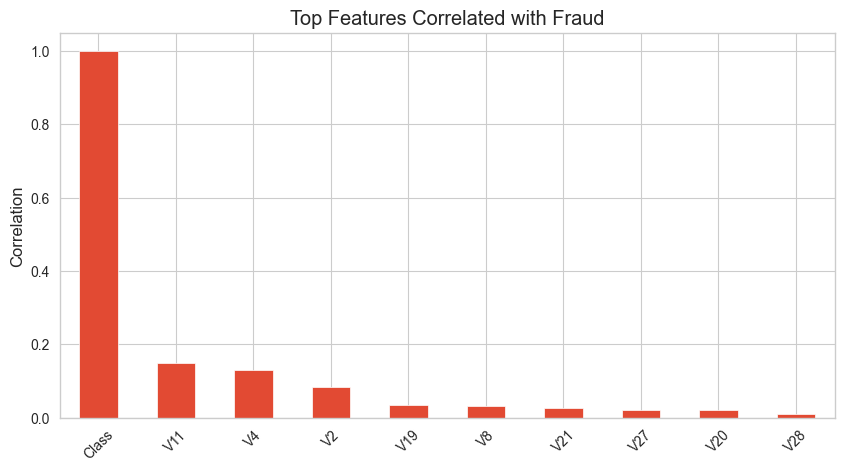

In [97]:
# ==========================================================
# Top 10 Features Correlated with Fraud
# ==========================================================

top_corr = fraud_corr.head(10)

plt.figure(figsize=(10,5))

top_corr.plot(kind="bar")

plt.title("Top Features Correlated with Fraud")

plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()

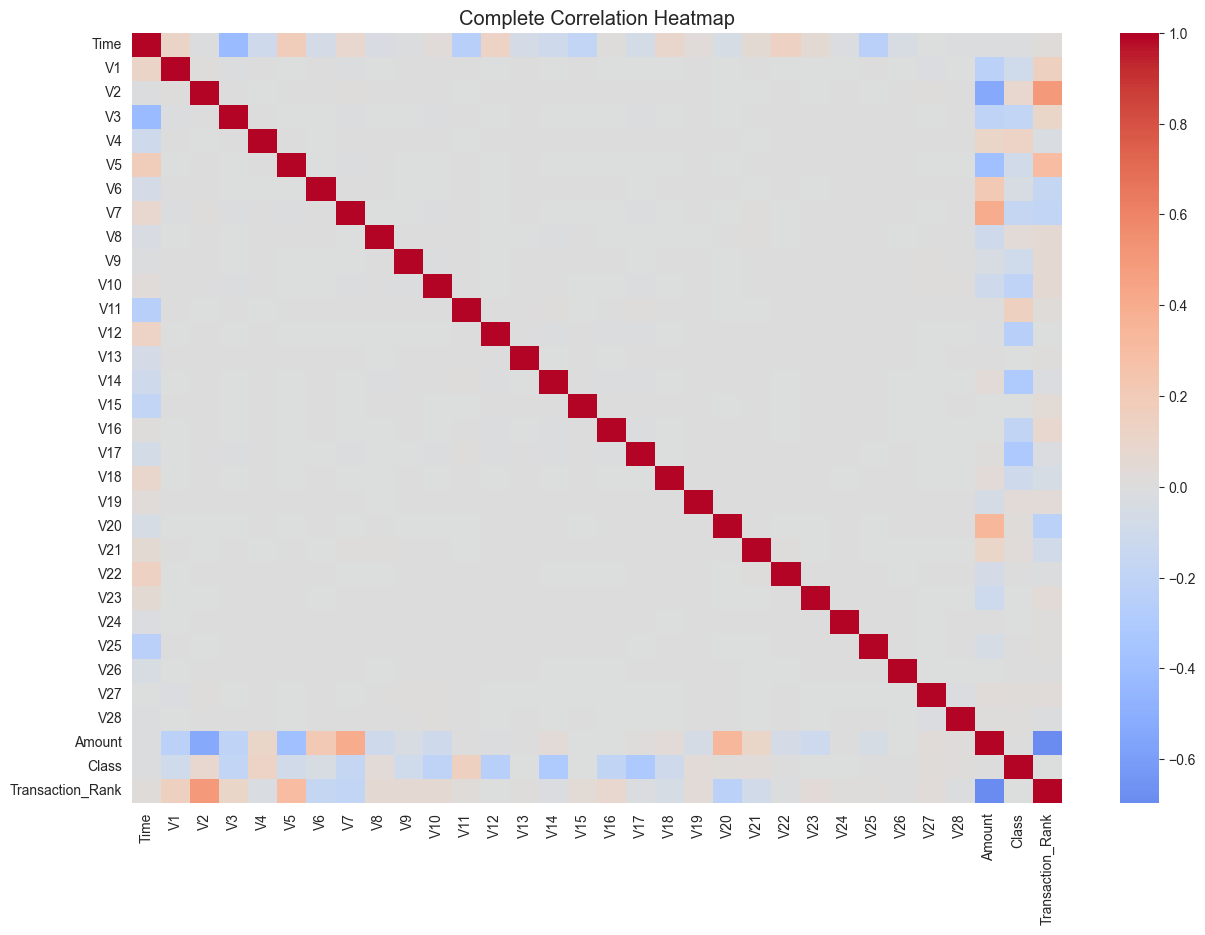

In [98]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Complete Correlation Heatmap")

plt.show()

# Statistical Insights

### Observations

- Transaction amounts show a positively skewed distribution.
- Fraudulent transactions represent a very small percentage of the dataset.
- Several anonymized features (V1–V28) exhibit meaningful correlations with the fraud label.
- The dataset is highly imbalanced, which is important to consider when building machine learning models.
- Statistical analysis supports the exploratory findings obtained through visualizations.

The next section will focus on Feature Engineering and Data Transformation.

# Feature Creation & Data Transformation

Feature creation improves the quality of the dataset by creating new variables and transforming existing ones.

Topics covered:
- Derived Columns
- Scaling
- Normalization
- Standardization
- Log Transformation
- Feature Selection

In [99]:
# ==========================================================
# Create Hour Feature
# ==========================================================

df["Hour"] = (df["Time"] // 3600).astype(int)

print("Hour feature created successfully!")

df[["Time", "Hour"]].head()

Hour feature created successfully!


,Time,Hour
0,0.0,0
1,0.0,0
2,1.0,0
3,1.0,0
4,2.0,0


In [100]:
# ==========================================================
# Log Transform Amount
# ==========================================================

import numpy as np

df["Log_Amount"] = np.log1p(df["Amount"])

df[["Amount", "Log_Amount"]].head()

,Amount,Log_Amount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


In [101]:
# ==========================================================
# Normalize Amount
# ==========================================================

from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

df["Normalized_Amount"] = minmax.fit_transform(df[["Amount"]])

df[["Amount", "Normalized_Amount"]].head()

,Amount,Normalized_Amount
0,149.62,0.005824
1,2.69,0.000105
2,378.66,0.014739
3,123.50,0.004807
4,69.99,0.002724


In [102]:
# ==========================================================
# Standardize Amount
# ==========================================================

from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

df["Standardized_Amount"] = standard.fit_transform(df[["Amount"]])

df[["Amount", "Standardized_Amount"]].head()

,Amount,Standardized_Amount
0,149.62,0.244200
1,2.69,-0.342584
2,378.66,1.158900
3,123.50,0.139886
4,69.99,-0.073813


In [103]:
# ==========================================================
# Create High Value Transaction Flag
# ==========================================================

df["High_Value"] = np.where(df["Amount"] > 200, 1, 0)

df[["Amount", "High_Value"]].head()

,Amount,High_Value
0,149.62,0
1,2.69,0
2,378.66,1
3,123.50,0
4,69.99,0


In [104]:
# ==========================================================
# Check New Features
# ==========================================================

new_features = [
    "Hour",
    "Log_Amount",
    "Normalized_Amount",
    "Standardized_Amount",
    "High_Value"
]

df[new_features].head(10)

,Hour,Log_Amount,Normalized_Amount,Standardized_Amount,High_Value
0,0,5.014760,0.005824,0.244200,0
1,0,1.305626,0.000105,-0.342584,0
2,0,5.939276,0.014739,1.158900,1
3,0,4.824306,0.004807,0.139886,0
4,0,4.262539,0.002724,-0.073813,0
5,0,1.541159,0.000143,-0.338670,0
6,0,1.790091,0.000194,-0.333399,0
7,0,3.732896,0.001588,-0.190387,0
8,0,4.545420,0.003628,0.018879,0
9,0,1.543298,0.000143,-0.338630,0


In [105]:
# ==========================================================
# Correlation of New Features
# ==========================================================

new_corr = df[new_features + ["Class"]].corr()

new_corr

,Hour,Log_Amount,Normalized_Amount,Standardized_Amount,High_Value,Class
Hour,1.000000,-0.028352,-0.010635,-0.010635,-0.010086,-0.012371
Log_Amount,-0.028352,1.000000,0.551830,0.551830,0.587701,-0.007798
Normalized_Amount,-0.010635,0.551830,1.000000,1.000000,0.612767,0.005777
Standardized_Amount,-0.010635,0.551830,1.000000,1.000000,0.612767,0.005777
High_Value,-0.010086,0.587701,0.612767,0.612767,1.000000,0.009742
Class,-0.012371,-0.007798,0.005777,0.005777,0.009742,1.000000


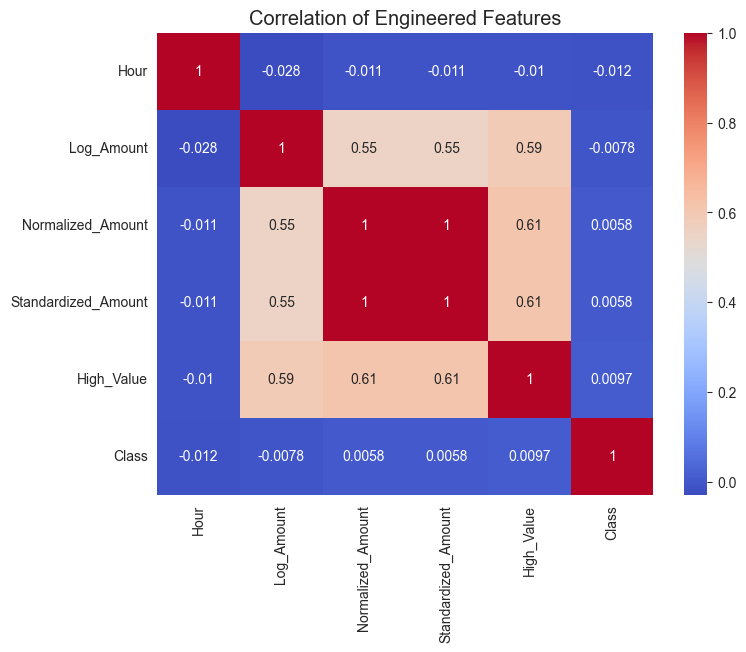

In [106]:
# ==========================================================
# Heatmap of Engineered Features
# ==========================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    new_corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation of Engineered Features")

plt.show()

In [107]:
# ==========================================================
# Export Final Dataset for Power BI / ML
# ==========================================================

from pathlib import Path

desktop = Path.home() / "Desktop"

final_path = desktop / "final_creditcard_dataset.csv"

df.to_csv(final_path, index=False)

print("✅ Final dataset exported successfully!")
print(final_path)

✅ Final dataset exported successfully!
/Users/s/Desktop/final_creditcard_dataset.csv


# Time-Based Transaction Analysis

This section analyzes transaction activity over time using the engineered **Hour** feature. Understanding when transactions occur can help identify behavioral patterns and support fraud detection strategies.

In [108]:
# ==========================================================
# Transactions by Hour
# ==========================================================

hourly_transactions = (
    df.groupby("Hour")
      .size()
      .reset_index(name="Total_Transactions")
)

hourly_transactions

,Hour,Total_Transactions
0,0,3931
1,1,2213
2,2,1573
3,3,1818
4,4,1082
5,5,1679
6,6,1822
7,7,3366
8,8,5148
9,9,7841


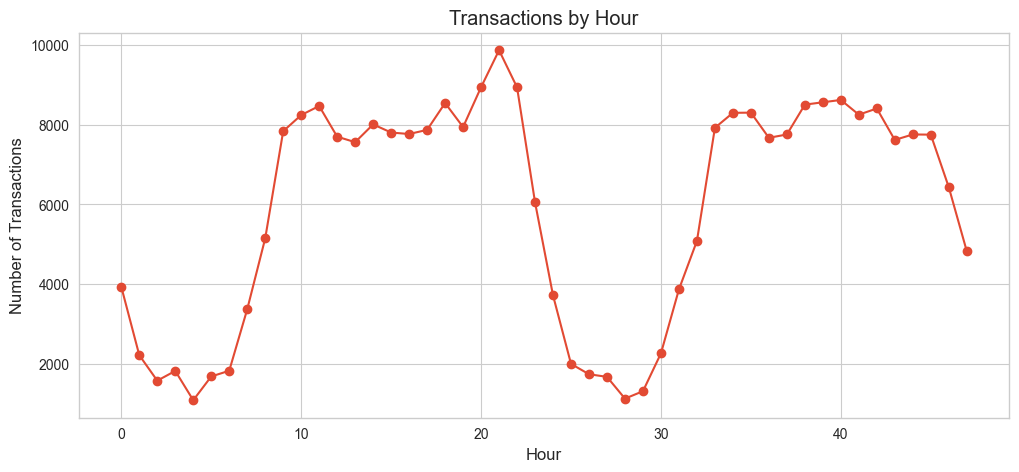

In [109]:
# ==========================================================
# Hourly Transaction Chart
# ==========================================================

plt.figure(figsize=(12,5))

plt.plot(
    hourly_transactions["Hour"],
    hourly_transactions["Total_Transactions"],
    marker="o"
)

plt.title("Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

plt.grid(True)

plt.show()

In [110]:
# ==========================================================
# Fraud Transactions by Hour
# ==========================================================

fraud_hourly = (
    df[df["Class"] == 1]
    .groupby("Hour")
    .size()
    .reset_index(name="Fraud_Transactions")
)

fraud_hourly

,Hour,Fraud_Transactions
0,0,2
1,1,2
2,2,21
3,3,13
4,4,6
5,5,11
6,6,3
7,7,23
8,8,5
9,9,15


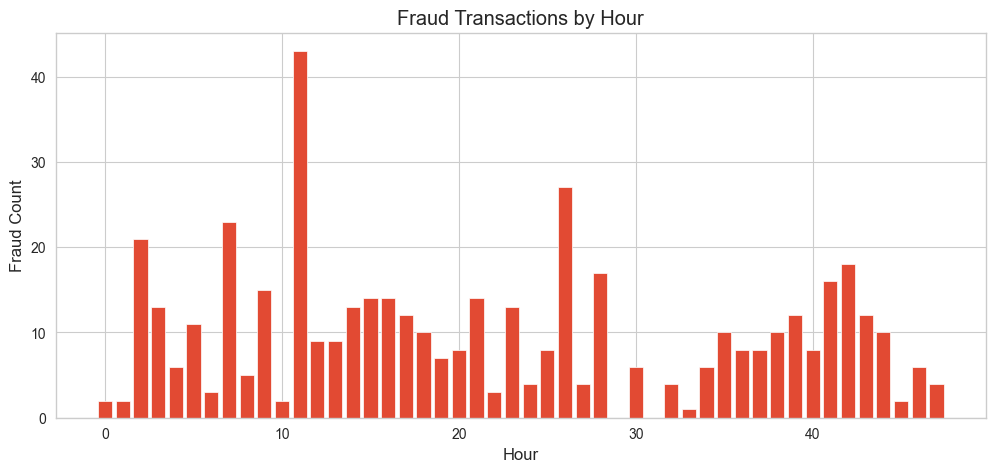

In [111]:
# ==========================================================
# Fraud Trend by Hour
# ==========================================================

plt.figure(figsize=(12,5))

plt.bar(
    fraud_hourly["Hour"],
    fraud_hourly["Fraud_Transactions"]
)

plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Count")

plt.show()

# Business Insights

## Key Insights

- The dataset is highly imbalanced, with legitimate transactions greatly outnumbering fraudulent ones.
- Most transactions involve relatively small amounts, while a small number of high-value transactions create a long-tailed distribution.
- Certain anonymized features show stronger relationships with fraudulent activity.
- Time-based analysis can help identify periods with relatively higher fraud occurrence.
- Feature engineering improved the dataset by adding useful analytical variables.

# Recommendations

1. Monitor high-value transactions with additional verification.
2. Continuously track transaction patterns over time.
3. Use engineered features to improve fraud detection models.
4. Combine statistical analysis with machine learning for better fraud prediction.
5. Develop interactive dashboards for continuous monitoring and reporting.

# Project Conclusion

This project demonstrated a complete data analytics workflow using a real-world credit card transaction dataset.

The workflow included:
- Data loading
- Data cleaning
- Exploratory Data Analysis (EDA)
- Data visualization
- Advanced Pandas operations
- SQL and SQLite analysis
- Statistical analysis
- Feature engineering
- Data transformation
- Exporting the processed dataset for dashboarding and future machine learning applications.

The project highlights how data analytics techniques can support fraud detection and business decision-making.

In [112]:
# ==========================================================
# Final Dataset Validation
# ==========================================================

print("Final Dataset Shape:", df.shape)

print("\nColumns:")

print(df.columns.tolist())

print("\nMissing Values:")

print(df.isnull().sum())

Final Dataset Shape: (283726, 38)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Amount_Category', 'Transaction_Rank', 'Hour', 'Log_Amount', 'Normalized_Amount', 'Standardized_Amount', 'High_Value']

Missing Values:
Time                   0
V1                     0
V2                     0
V3                     0
V4                     0
V5                     0
V6                     0
V7                     0
V8                     0
V9                     0
V10                    0
V11                    0
V12                    0
V13                    0
V14                    0
V15                    0
V16                    0
V17                    0
V18                    0
V19                    0
V20                    0
V21                    0
V22                    0
V23                    0
V24  

# Project Completed Successfully

## Project Name

**Banking Fraud Detection and Transaction Analysis using Python, SQL, and Data Analytics**

### Tools Used
- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- SQLite
- Scikit-learn

### Skills Demonstrated
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Statistical Analysis
- SQL Queries
- Advanced Pandas
- Data Visualization
- Feature Creation
- Data Transformation
- Dashboard Dataset Preparation

**Status:** Project Completed Successfully.